<img src="https://upload.wikimedia.org/wikipedia/en/thumb/f/f2/Premier_League_Logo.svg/960px-Premier_League_Logo.svg.png"/>

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Dosyaları yükleyelim
matches = pd.read_csv('Data/Fifa/england-premier-league-matches-2018-to-2019-stats.csv')
teams = pd.read_csv('Data/Fifa/england-premier-league-teams-2018-to-2019-stats.csv')

In [16]:
# Eksik olan ortalama isabetli şut verisini hesaplayalım
teams['shots_on_target_avg'] = teams['shots_on_target'] / teams['matches_played']

# Modelde kullanacağımız temel takım özelliklerini seçelim
team_features = teams[['common_name', 'points_per_game', 'average_possession', 'shots_on_target_avg']]

# Maçlar tablosuna bu özellikleri hem ev sahibi hem deplasman için ekleyelim
df = matches.merge(team_features, left_on='home_team_name', right_on='common_name', how='left')
df = df.merge(team_features, left_on='away_team_name', right_on='common_name', how='left', suffixes=('_home', '_away'))

In [17]:
# Hedef Değişkeni: 1 (Ev), 0 (Beraberlik), 2 (Deplasman)
def get_result(row):
    if row['home_team_goal_count'] > row['away_team_goal_count']: return 1
    if row['home_team_goal_count'] < row['away_team_goal_count']: return 2
    return 0

df['target'] = df.apply(get_result, axis=1)

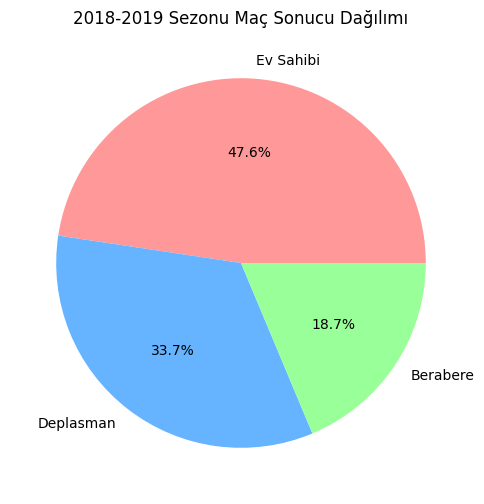

In [18]:
# 1. Maç Sonucu Dağılımı
plt.figure(figsize=(8, 6))
result_counts = df['target'].value_counts()
plt.pie(result_counts, labels=['Ev Sahibi', 'Deplasman', 'Berabere'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('2018-2019 Sezonu Maç Sonucu Dağılımı')
plt.show()

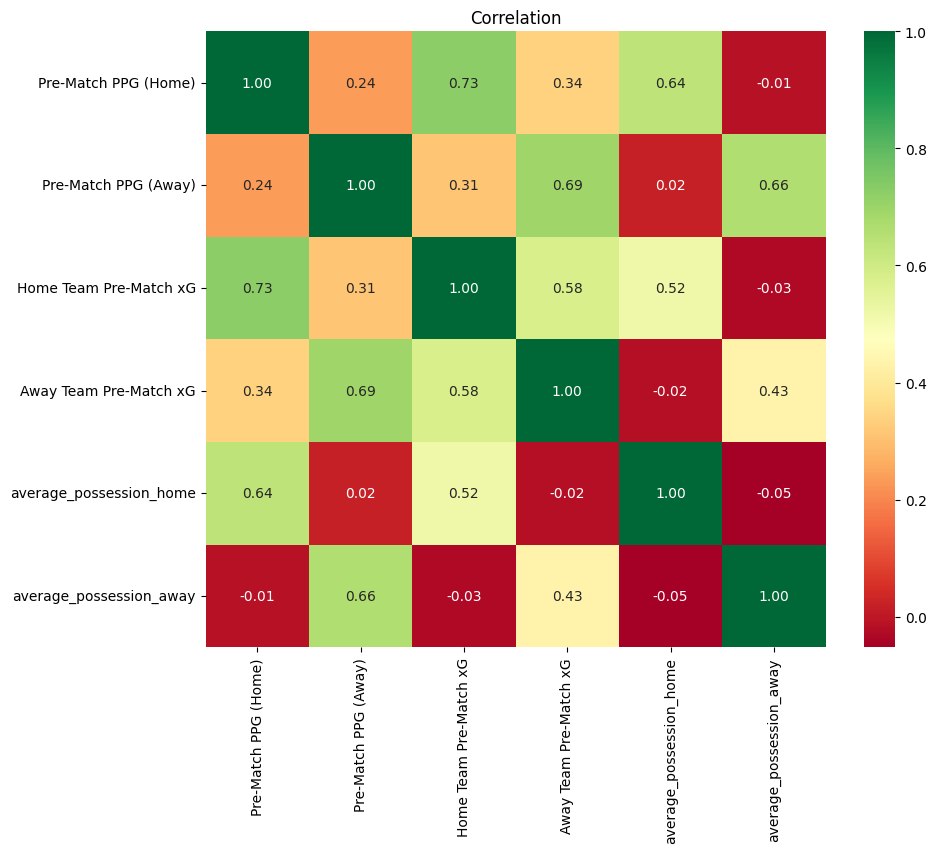

In [21]:
# 2. xG ve PPG Korelasyonu
plt.figure(figsize=(10, 8))
corr_cols = ['Pre-Match PPG (Home)', 'Pre-Match PPG (Away)', 'Home Team Pre-Match xG', 'Away Team Pre-Match xG', 'average_possession_home', 'average_possession_away']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation')
plt.show()

In [22]:
# Eğitim için kullanılacak sütunlar
# Sadece maç başlamadan önce bilinen verileri seçiyoruz
X = df[[
    'Pre-Match PPG (Home)', 'Pre-Match PPG (Away)', 
    'average_possession_home', 'average_possession_away',
    'shots_on_target_avg_home', 'shots_on_target_avg_away',
    'Home Team Pre-Match xG', 'Away Team Pre-Match xG'
]]
y = df['target']

In [23]:
# Veriyi böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli eğit
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Tahmin ve Başarı Ölçümü
preds = model.predict(X_test)
print(f"Maç Sonucu Tahmin Başarısı: %{accuracy_score(y_test, preds) * 100:.2f}")

Maç Sonucu Tahmin Başarısı: %60.53
